# Transformer-based Text Generation (Fine-Tuning GPT-2)

This notebook implements a transformer-based text generation model
using a pre-trained GPT-2 model fine-tuned on the Shakespeare corpus.

This experiment serves as Part 3 of a comparative study:
- N-gram Language Model
- RNN / LSTM
- Transformer (Fine-tuned GPT-2)

The goal is to balance training time and generation quality
using limited computational resources (Google Colab GPU).


#Setup

###Install Dependencies

In [26]:
!pip install -q transformers datasets accelerate torch wandb

###Imports


In [50]:
import torch
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


from datasets import load_dataset
import os, requests
from datasets import Dataset
from transformers import (
    EarlyStoppingCallback,
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

import wandb

### login to Weights & Biases

In [28]:
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

###Connect to GPU

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


### Connect to drive and define paths

In [30]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

drive_dir = "/content/drive/MyDrive/KP_MODEL"
os.makedirs(drive_dir, exist_ok=True)

checkpoint_path_gpt2= os.path.join(drive_dir, "gpt2_shakespeare")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Load data

In [31]:
cache_dir = "./tmp"
os.makedirs(cache_dir, exist_ok=True)

dataset_file_name = "shakespeare.txt"
dataset_file_origin = "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"

file_path = os.path.join(cache_dir, dataset_file_name)

if not os.path.exists(file_path):
    print("Downloading dataset ...")
    data = requests.get(dataset_file_origin).text
    with open(file_path, "w", encoding="utf-8") as f:
        f.write(data)
    print("Download complete.")
else:
    print("Dataset already exists.")

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

print("Text characters length:", len(text))

# Convert to HF Dataset (IMPORTANT)
dataset = Dataset.from_dict({"text": [text]})
dataset

Dataset already exists.
Text characters length: 1115394


Dataset({
    features: ['text'],
    num_rows: 1
})

###Load Model & Tokenizer

In [32]:
MODEL_NAME = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)


###Tokenization

In [33]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=False,
         return_attention_mask=False
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)


Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (338025 > 1024). Running this sequence through the model will result in indexing errors


###Chunk Text into Fixed Blocks

In [34]:
block_size = 128

def group_texts(examples):
    concatenated = sum(examples["input_ids"], [])
    total_length = (len(concatenated) // block_size) * block_size

    input_ids = [
        concatenated[i:i + block_size]
        for i in range(0, total_length, block_size)
    ]

    return {
        "input_ids": input_ids,
        "labels": input_ids.copy()
    }


In [35]:
lm_dataset = tokenized_dataset.map(group_texts, batched=True)
lm_dataset

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'labels'],
    num_rows: 2640
})

###Train / Validation / Test Split

In [36]:
split1 = lm_dataset.train_test_split(test_size=0.1, seed=42)
train_val_dataset = split1["train"]
test_dataset = split1["test"]

split2 = train_val_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split2["train"]
eval_dataset = split2["test"]

len(train_dataset), len(eval_dataset), len(test_dataset)


(2138, 238, 264)

###Data Collator

In [37]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

#Training Arguments

In [38]:
training_args = TrainingArguments(
    output_dir=checkpoint_path_gpt2,
    eval_strategy="steps",
    eval_steps=500,
    logging_steps=100,
    save_steps=500,
    save_total_limit=2,

    num_train_epochs=6,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    learning_rate=5e-5,
    weight_decay=0.01,
    fp16=True,

    report_to="wandb",
    run_name="GPT2-Shakespeare-Finetuning",

    load_best_model_at_end=True
)

###Trainer

In [40]:
trainer = Trainer(
      model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
)


/tmp/ipython-input-2312235712.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [41]:
import os

checkpoint_dir = checkpoint_path_gpt2  # same as TrainingArguments.output_dir

has_checkpoint = (
    os.path.exists(checkpoint_dir)
    and any(name.startswith("checkpoint-") for name in os.listdir(checkpoint_dir))
)

if has_checkpoint:
    print("Checkpoint found → resuming training")
    trainer.train(resume_from_checkpoint=True)
else:
    print("No checkpoint found → starting fresh training")
    trainer.train()


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.


Checkpoint found → resuming training


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].
There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Step,Training Loss,Validation Loss


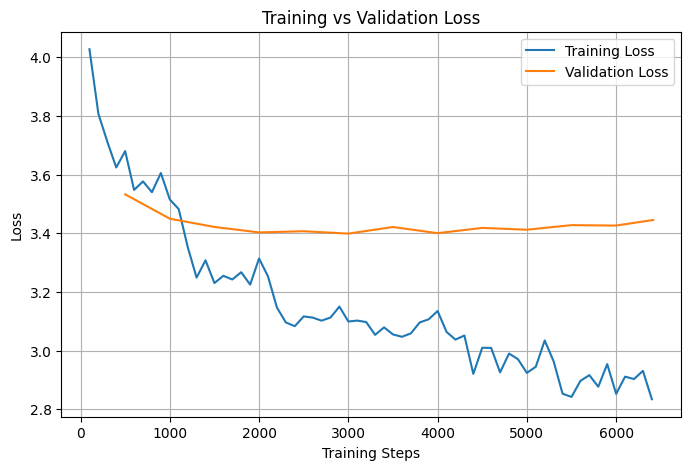

In [56]:
log_history = pd.DataFrame(trainer.state.log_history)
train_logs = log_history[log_history["loss"].notna()]

val_logs = log_history[log_history["eval_loss"].notna()]
val_logs.head()

plt.figure(figsize=(8,5))
plt.plot(train_logs["step"], train_logs["loss"], label="Training Loss")
plt.plot(val_logs["step"], val_logs["eval_loss"], label="Validation Loss")

plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

#Evaluate on Shakespeare TEST Data

In [52]:
test_metrics = trainer.evaluate(test_dataset)
test_metrics

{'eval_loss': 3.445317029953003,
 'eval_runtime': 7.1438,
 'eval_samples_per_second': 36.955,
 'eval_steps_per_second': 18.477,
 'epoch': 6.0}

#Perplexity

In [44]:
test_perplexity = math.exp(test_metrics["eval_loss"])
print("Shakespeare Test Perplexity:", test_perplexity)


Shakespeare Test Perplexity: 31.35322178163913


#Evaluate on RANDOM Wikipedia Text

In [45]:
wiki_text = """
Artificial intelligence is intelligence demonstrated by machines,
as opposed to the natural intelligence displayed by humans and animals.
"""

inputs = tokenizer(
    wiki_text,
    return_tensors="pt",
    truncation=True,
    max_length=128
).to(model.device)

with torch.no_grad():
    outputs = model(**inputs, labels=inputs["input_ids"])

wiki_loss = outputs.loss.item()
wiki_perplexity = math.exp(wiki_loss)

print("Wikipedia Loss:", wiki_loss)
print("Wikipedia Perplexity:", wiki_perplexity)


Wikipedia Loss: 5.270156383514404
Wikipedia Perplexity: 194.44636827427954


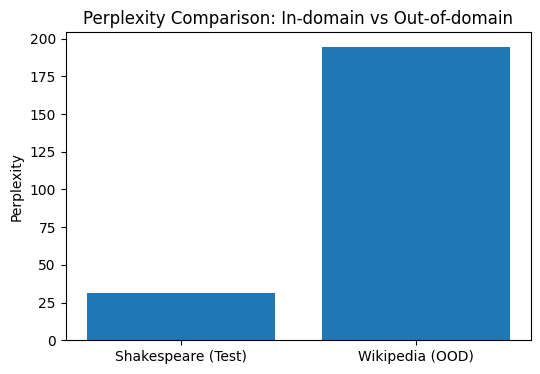

In [61]:

datasets = ["Shakespeare (Test)", "Wikipedia (OOD)"]
perplexities = [test_perplexity, wiki_perplexity]

plt.figure(figsize=(6,4))
plt.bar(datasets, perplexities)

plt.ylabel("Perplexity")
plt.title("Perplexity Comparison: In-domain vs Out-of-domain")
plt.grid(axis="y")
plt.grid(False)

plt.show()

In [46]:
def generate_text(prompt, max_length=200):
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            temperature=0.7,
            top_k=40,
            top_p=0.9,
            do_sample=True
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


In [47]:
print(generate_text("To be, or not to be:"))
print(generate_text("My lord, I pray thee hear me speak"))


To be, or not to be: for you have done it
To help us to the house of York,
That Henry, with his royal son,
May live, and with him Richard, king of England
And all the rest, to be king of England.

KING RICHARD II:
You have done it.

QUEEN ELIZABETH:
I have done it, and have done it withal.

KING RICHARD II:
And have done it withal.

QUEEN ELIZABETH:
And have done it withal.

KING RICHARD II:
And have done it withal.

QUEEN ELIZABETH:
And have done it withal.

KING RICHARD II:
And have done it withal.

QUEEN ELIZABETH:
And have done it withal.

KING RICH
My lord, I pray thee hear me speak.

GLOUCESTER:
My lord, I will hear thee speak;
For, as I say, I am a subject unto thee:
And, as I say, I am a subject unto thee;
And, as I say, I am a subject unto thee;
For, as I say, I am a subject unto thee;
And, as I say, I am a subject unto thee;
And, as I say, I am a subject unto thee;
For, as I say, I am a subject unto thee;
For, as I say, I am a subject unto thee;
And, as I say, I am a subject 

###Save Final Model

In [42]:
FINAL_MODEL_PATH = "/content/drive/MyDrive/KP_Models/gpt2_shakespeare_final"

trainer.save_model(FINAL_MODEL_PATH)
tokenizer.save_pretrained(FINAL_MODEL_PATH)

print("Final model saved.")


Final model saved.
